In [1]:
import numpy as np
import rioxarray as rio
import matplotlib.pyplot as plt
import skimage.morphology as skimage_morphology
from matplotlib.colors import TwoSlopeNorm
from skimage.morphology import remove_small_objects, binary_closing, binary_opening, disk, dilation
from skimage.measure import label, regionprops
from scipy.ndimage import binary_dilation as scipy_dilation

In [23]:
def open_band(path):
    """
    Opens a single HLS band GeoTIFF file, reprojects it to WGS84 (EPSG:4326), masks fill values, 
    and applies a HLS reflectance scale factor.

    Parameters
    ----------
    path : str
        File path to the HLS GeoTIFF band file.

    Returns
    -------
    xarray.DataArray
        A 2D spatial array of surface reflectance values in the range
        0.0 to 1.0. Fill values (-9999) are masked as NaN.
    """
    band_data = rio.open_rasterio(path).rio.reproject("EPSG:4326")
    band_data = band_data.where(band_data != -9999)
    band_data = (band_data * 0.0001).astype("float32")
    return band_data

In [ ]:
def hail_swath_identification(R_before, NIR_before, R_after, NIR_after, swath_threshold, min_blob_size, dilation_disk_size, prox_filter):
    """
        Identifies and visualizes a hail swath from before and after HLS satellite
        imagery using NDVI differencing and morphology from scimage.

        The function calculates NDVI for both time periods, computes the difference
        to isolate vegetation loss, and applies a series of filters to isolate the
        hail swath from agricultural noise. Results are displayed as a
        side-by-side plot of the raw NDVI difference and the detected swath.

        Parameters
        ----------
        R_before : xarray.DataArray
            Red band (B04) surface reflectance from the before image.
        NIR_before : xarray.DataArray
            Near-infrared band (B8A) surface reflectance from the before image.
        R_after : xarray.DataArray
            Red band (B04) surface reflectance from the after image.
        NIR_after : xarray.DataArray
            Near-infrared band (B8A) surface reflectance from the after image.
        swath_threshold : float
            NDVI difference value below which a pixel is flagged as potentially
            hail damaged. Negative values indicate vegetation loss.
        min_blob_size : int
            Minimum number of connected pixels required to keep a region. Any
            connected region smaller than this is discarded as noise.
        dilation_disk_size : int
            Number of dilations applied to the largest detected blob to
            create a proximity area. Only used when prox_filter is True.
        prox_filter : bool
            If True, applies the proximity filter which focuses on the largest
            detected blob and keeps only nearby blobs within the dilation area. 
            If False, all blobs that pass the size filter are plotted.

        Returns
        -------
        swath_diff : numpy.ndarray
            2D array of NDVI difference values where the hail swath was detected.
            Non-swath pixels are set to NaN.

        """
    ndvi_before = (NIR_before - R_before) / (NIR_before + R_before + 1e-10)
    ndvi_after  = (NIR_after  - R_after)  / (NIR_after  + R_after  + 1e-10)

    ndvi_before = ndvi_before.where((ndvi_before >= -1) & (ndvi_before <= 1))
    ndvi_after  = ndvi_after.where((ndvi_after  >= -1) & (ndvi_after  <= 1))

    diff = (ndvi_after - ndvi_before) / 2.0
    diff = diff.squeeze()

    swath_mask = diff < swath_threshold
    swath_mask = swath_mask.squeeze()
    swath_mask = skimage_morphology.opening(swath_mask, disk(2))
    swath_mask = skimage_morphology.closing(swath_mask, disk(20))
    swath_mask = remove_small_objects(swath_mask, max_size=min_blob_size)

    if prox_filter == True:
        swath_labeled = label(swath_mask)
        swath_regionprops = regionprops(swath_labeled)

        biggest_blob = max(swath_regionprops, key=lambda r: r.area)
        swath_only = (swath_labeled == biggest_blob.label)
        swath_area = scipy_dilation(swath_only, iterations=dilation_disk_size)

        final_mask = swath_only.copy()
        for blob in swath_regionprops:
            this_blob = (swath_labeled == blob.label)
            if np.any(this_blob & swath_area):
                final_mask = final_mask | this_blob

    else:
        final_mask = swath_mask
    
    swath_diff = np.where(final_mask, diff.squeeze(), np.nan)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

    im1 = axes[0].imshow(diff, cmap='RdYlGn', norm=norm)
    axes[0].set_title('NDVI Difference')
    axes[0].axis('off')

    im2 = axes[1].imshow(swath_diff, cmap='RdYlGn', norm=norm)
    axes[1].set_title('Detected Hail Swath')
    axes[1].axis('off')
    plt.colorbar(im2, ax=axes[1], label='NDVI Difference')

    plt.suptitle('Hail Swath Detection', fontsize=14)
    plt.tight_layout()
    plt.show()  

    return swath_diff

In [4]:
R_p1_before = open_band(r"C:\Users\thewe\OneDrive\Desktop\final_tifs\pristine\IA_p_before\HLS.S30.T14TQN.2020190T170849.v2.0.B04.tif")
NIR_p1_before = open_band(r"C:\Users\thewe\OneDrive\Desktop\final_tifs\pristine\IA_p_before\HLS.S30.T14TQN.2020190T170849.v2.0.B8A.tif")

R_p1_after = open_band(r"C:\Users\thewe\OneDrive\Desktop\final_tifs\pristine\IA_p_after\HLS.S30.T14TQN.2021184T170849.v2.0.B04.tif")
NIR_p1_after = open_band(r"C:\Users\thewe\OneDrive\Desktop\final_tifs\pristine\IA_p_after\HLS.S30.T14TQN.2021184T170849.v2.0.B8A.tif")

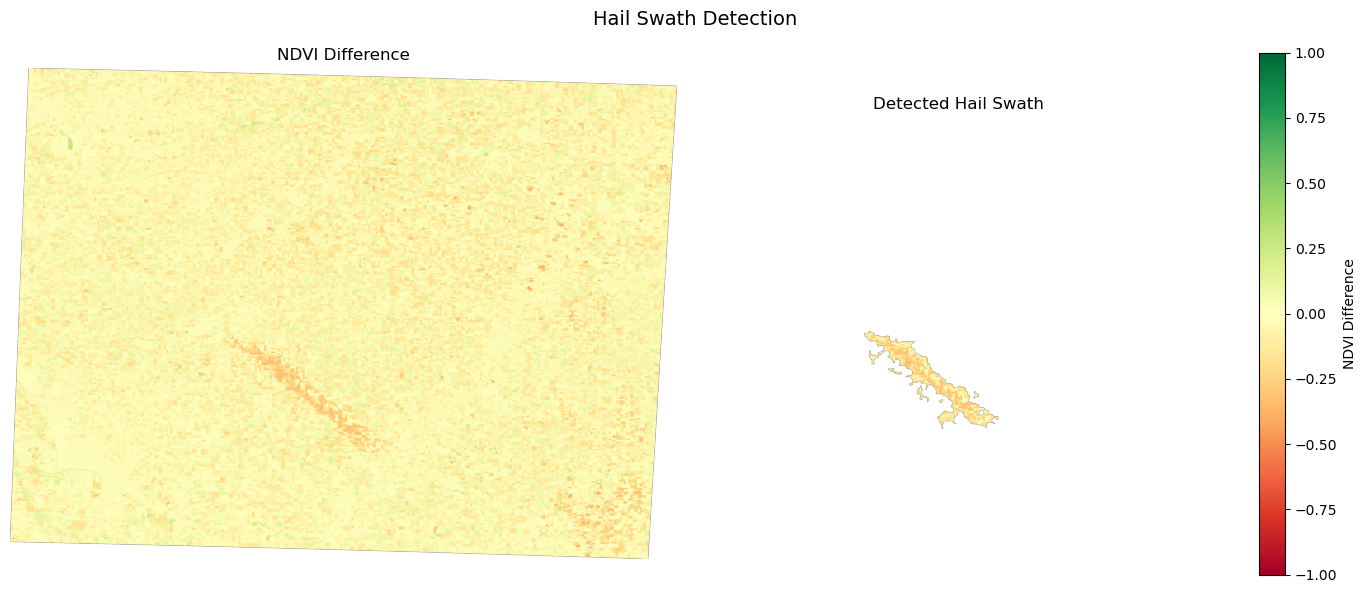

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(3215, 4368), dtype=float32)

In [18]:
hail_swath_identification(R_p1_before, NIR_p1_before, R_p1_after, NIR_p1_after, -0.18, 500, 50, True)

In [6]:
R_p2_before = open_band(r"C:\Users\thewe\OneDrive\Desktop\final_tifs\pristine\SD_p_before\HLS.S30.T14TNR.2021227T171859.v2.0.B04.tif")
NIR_p2_before = open_band(r"C:\Users\thewe\OneDrive\Desktop\final_tifs\pristine\SD_p_before\HLS.S30.T14TNR.2021227T171859.v2.0.B8A.tif")

R_p2_after = open_band(r"C:\Users\thewe\OneDrive\Desktop\final_tifs\pristine\SD_p_after\HLS.S30.T14TNR.2021247T171849.v2.0.B04.tif")
NIR_p2_after = open_band(r"C:\Users\thewe\OneDrive\Desktop\final_tifs\pristine\SD_p_after\HLS.S30.T14TNR.2021247T171849.v2.0.B8A.tif")

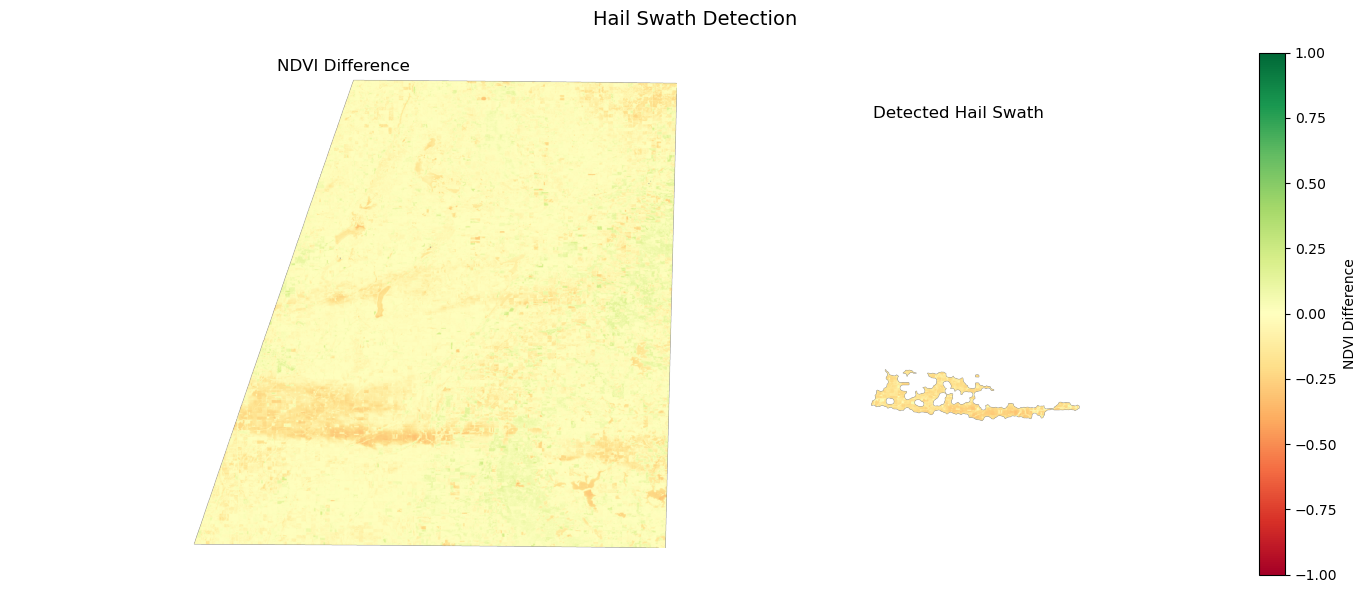

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(3010, 4285), dtype=float32)

In [19]:
hail_swath_identification(R_p2_before, NIR_p2_before, R_p2_after, NIR_p2_after, -0.18, 500, 50, True)

In [8]:
R_sp1_before = open_band(r"C:\Users\thewe\OneDrive\Desktop\final_tifs\pristine\MT_p_before\HLS.S30.T12UVU.2024165T181921.v2.0.B04.tif")
NIR_sp1_before = open_band(r"C:\Users\thewe\OneDrive\Desktop\final_tifs\pristine\MT_p_before\HLS.S30.T12UVU.2024165T181921.v2.0.B8A.tif")

R_sp1_after = open_band(r"C:\Users\thewe\OneDrive\Desktop\final_tifs\pristine\MT_p_after\HLS.S30.T12UVU.2024195T181921.v2.0.B04.tif")
NIR_sp1_after = open_band(r"C:\Users\thewe\OneDrive\Desktop\final_tifs\pristine\MT_p_after\HLS.S30.T12UVU.2024195T181921.v2.0.B8A.tif")

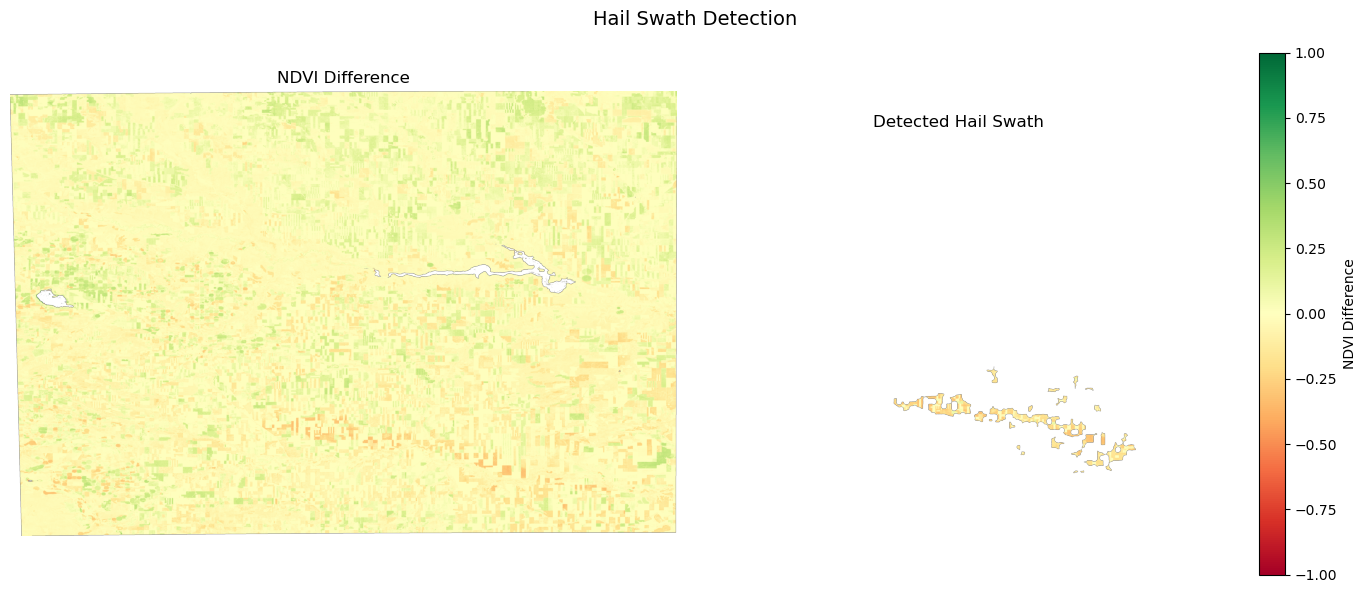

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(2888, 4333), dtype=float32)

In [20]:
hail_swath_identification(R_sp1_before, NIR_sp1_before, R_sp1_after, NIR_sp1_after, -0.15, 200, 300, True)

In [10]:
R_st1_before = open_band(r"C:\Users\thewe\OneDrive\Desktop\final_tifs\stress-test\MT-before\HLS.S30.T12TYR.2024204T175919.v2.0.B04.tif")
NIR_st1_before = open_band(r"C:\Users\thewe\OneDrive\Desktop\final_tifs\stress-test\MT-before\HLS.S30.T12TYR.2024204T175919.v2.0.B8A.tif")

R_st1_after = open_band(r"C:\Users\thewe\OneDrive\Desktop\final_tifs\stress-test\MT-after\HLS.S30.T12TYR.2024237T180919.v2.0.B04.tif")
NIR_st1_after = open_band(r"C:\Users\thewe\OneDrive\Desktop\final_tifs\stress-test\MT-after\HLS.S30.T12TYR.2024237T180919.v2.0.B8A.tif")

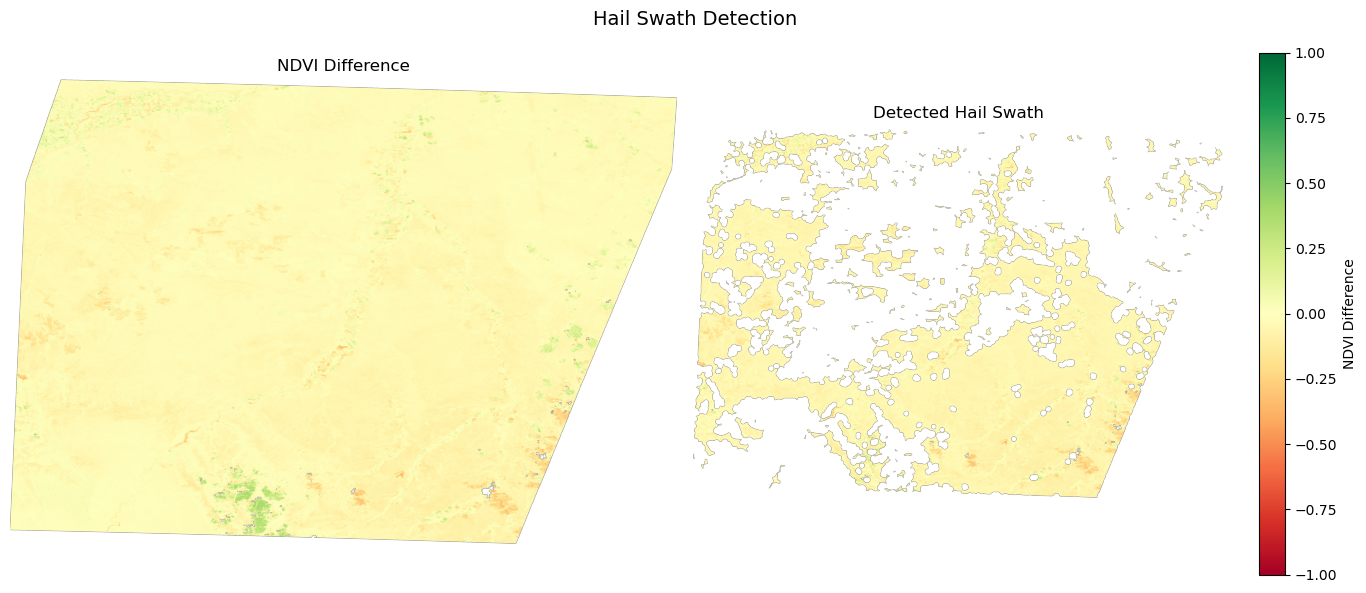

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(3139, 4465), dtype=float32)

In [21]:
hail_swath_identification(R_st1_before, NIR_st1_before, R_st1_after, NIR_st1_after, -0.05, 50, 30, False)